In [5]:
# import
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score




In [6]:
# Choisire les variables
features = [
    'Surface_m2',
    'Nb_Chambres',
    'Nb_Salles_Bain',
    'Nb_Etages',
    'Nb_Salons',
    'Nb_Cuisines',
    'Parking',
    'Ascenseur',
    'Jardin',
    'Internet',
    'Climatisation'
]

target = 'Prix_CFA'


In [7]:
import pandas as pd

df_location = pd.read_csv("../data/df_location.csv")
df_vente = pd.read_csv("../data/df_vente.csv")


# Dataset Location

In [8]:
# Dataset Location
X_loc = df_location[features]
y_loc = df_location[target]

X_train_loc, X_test_loc, y_train_loc, y_test_loc = train_test_split(
    X_loc, y_loc, test_size=0.2, random_state=42
)


In [9]:
# Entraînement
model_loc = LinearRegression()
model_loc.fit(X_train_loc, y_train_loc)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Prédiction
y_pred_loc = model_loc.predict(X_test_loc)


In [11]:
# Évaluation
mae_loc = mean_absolute_error(y_test_loc, y_pred_loc)
r2_loc = r2_score(y_test_loc, y_pred_loc)

print("MAE Location :", mae_loc)
print("R2 Location :", r2_loc)


MAE Location : 664225.3575469737
R2 Location : 0.5588488359552339


# Dataset Vente

In [12]:
X_vente = df_vente[features]
y_vente = df_vente[target]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vente, y_vente, test_size=0.2, random_state=42
)

model_vente = LinearRegression()
model_vente.fit(X_train_v, y_train_v)

y_pred_v = model_vente.predict(X_test_v)

print("MAE Vente :", mean_absolute_error(y_test_v, y_pred_v))
print("R2 Vente :", r2_score(y_test_v, y_pred_v))


MAE Vente : 105736621.64562282
R2 Vente : 0.541795538509046


# RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# RANDOM FOREST → LOCATION

In [14]:
rf_loc = RandomForestRegressor(n_estimators=100, random_state=42)

rf_loc.fit(X_train_loc, y_train_loc)

y_pred_rf_loc = rf_loc.predict(X_test_loc)

mae_rf_loc = mean_absolute_error(y_test_loc, y_pred_rf_loc)
r2_rf_loc = r2_score(y_test_loc, y_pred_rf_loc)

print("Random Forest - Location")
print("MAE :", mae_rf_loc)
print("R2 :", r2_rf_loc)


Random Forest - Location
MAE : 828118.751201071
R2 : -0.7756701247326461


#  RANDOM FOREST → Vente

In [15]:
rf_vente = RandomForestRegressor(n_estimators=100, random_state=42)

rf_vente.fit(X_train_v, y_train_v)

y_pred_rf_v = rf_vente.predict(X_test_v)

mae_rf_v = mean_absolute_error(y_test_v, y_pred_rf_v)
r2_rf_v = r2_score(y_test_v, y_pred_rf_v)

print("Random Forest - Vente")
print("MAE :", mae_rf_v)
print("R2 :", r2_rf_v)


Random Forest - Vente
MAE : 125577964.32701996
R2 : 0.13307161204307516


# COMPARAISON DES MODÈLES

In [16]:
print("====== COMPARAISON ======")

print("LOCATION")
print("Linear Regression R2 :", r2_loc)
print("Random Forest R2 :", r2_rf_loc)

print("\nVENTE")
print("Linear Regression R2 :", r2_score(y_test_v, y_pred_v))
print("Random Forest R2 :", r2_rf_v)


====== COMPARAISON ======
LOCATION
Linear Regression R2 : 0.5588488359552339
Random Forest R2 : -0.7756701247326461

VENTE
Linear Regression R2 : 0.541795538509046
Random Forest R2 : 0.13307161204307516


In [4]:
# ================================
# 1️⃣ IMPORTS
# ================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


import pandas as pd

df_location_final = pd.read_csv("../data/df_location_final.csv")
df_vente_final = pd.read_csv("../data/df_vente_final.csv")

# ================================
# 2️⃣ PRÉPARATION DES DONNÉES
# ================================

def preparer_donnees(df):
    
    df = df.copy()
    
    #  supprimer colonnes inutiles
    df = df.drop(columns=['Titre', 'Description'], errors='ignore')
    
    #  supprimer Type_Annonce (inutile ici)
    df = df.drop(columns=['Type_Annonce'], errors='ignore')
    
    #  encodage Localisation
    if 'Localisation' in df.columns:
        df = pd.get_dummies(df, columns=['Localisation'], drop_first=True)
    
    #  SUPPRIMER TOUTES LES COLONNES NON NUMÉRIQUES
    df = df.select_dtypes(include=['int64', 'float64'])
    
    #  Target
    y = df['Prix_CFA']
    
    #  Features
    X = df.drop(columns=['Prix_CFA'])
    
    return X, y



# ================================
# 3️⃣ FONCTION ENTRAÎNEMENT
# ================================

def entrainer_modele(X, y):
    
    # Train / Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # ======================
    # Linear Regression
    # ======================
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred_lr = lr.predict(X_test)
    
    # ======================
    # Random Forest
    # ======================
    
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    y_pred_rf = rf.predict(X_test)
    
    # ======================
    # ÉVALUATION
    # ======================
    
    print("===== RÉSULTATS =====")
    
    print("\n--- Linear Regression ---")
    print("R2 :", r2_score(y_test, y_pred_lr))
    print("MAE :", mean_absolute_error(y_test, y_pred_lr))
    
    print("\n--- Random Forest ---")
    print("R2 :", r2_score(y_test, y_pred_rf))
    print("MAE :", mean_absolute_error(y_test, y_pred_rf))
    
    return lr, rf


# ================================
# 4️⃣ LOCATION
# ================================

print("\n==============================")
print("📊 DATASET LOCATION")
print("==============================")

X_loc, y_loc = preparer_donnees(df_location_final)

model_lr_loc, model_rf_loc = entrainer_modele(X_loc, y_loc)


# ================================
# 5️⃣ VENTE
# ================================

print("\n==============================")
print("📊 DATASET VENTE")
print("==============================")

X_vente, y_vente = preparer_donnees(df_vente_final)

model_lr_vente, model_rf_vente = entrainer_modele(X_vente, y_vente)



📊 DATASET LOCATION
===== RÉSULTATS =====

--- Linear Regression ---
R2 : 0.7410684711734594
MAE : 163811.83452152374

--- Random Forest ---
R2 : 0.8943160284776444
MAE : 68419.53128839377

📊 DATASET VENTE
===== RÉSULTATS =====

--- Linear Regression ---
R2 : 0.890916987581922
MAE : 13484665.088765629

--- Random Forest ---
R2 : 0.9662562483620624
MAE : 7103048.5495696645



 DATASET LOCATION

===== RÉSULTATS =====

--- Linear Regression ---
R2 : 0.7410684711734594
MAE : 163811.83452152374
RMSE : 393441.29486501985

--- Random Forest ---
R2 : 0.8943160284776444
MAE : 68419.53128839377
RMSE : 251357.60845325197

 DATASET VENTE

===== RÉSULTATS =====

--- Linear Regression ---
R2 : 0.890916987581922
MAE : 13484665.088765629
RMSE : 47320580.731957525

--- Random Forest ---
R2 : 0.9662562483620624
MAE : 7103048.5495696645
RMSE : 26318927.47362082


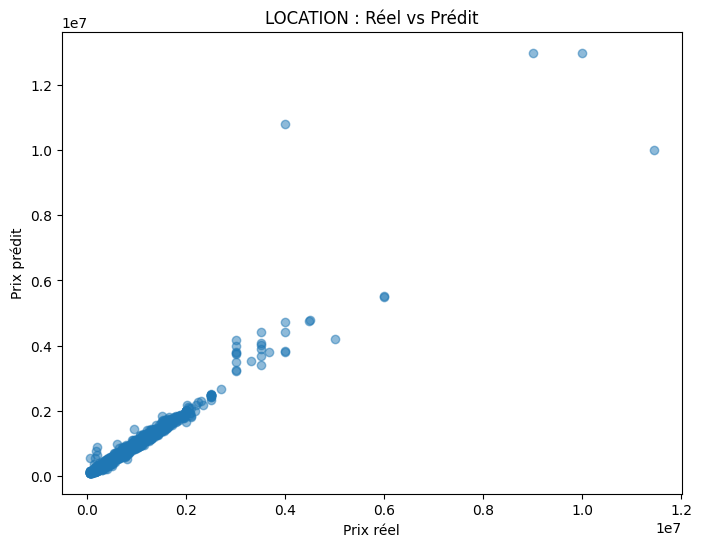

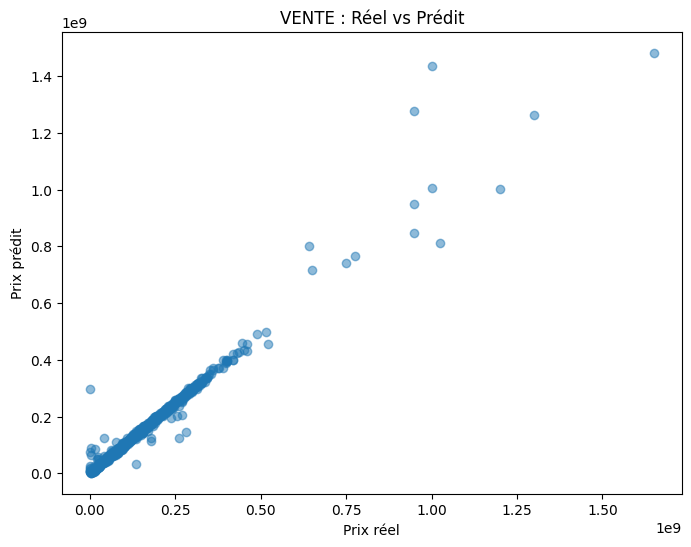

<Figure size 1000x600 with 0 Axes>

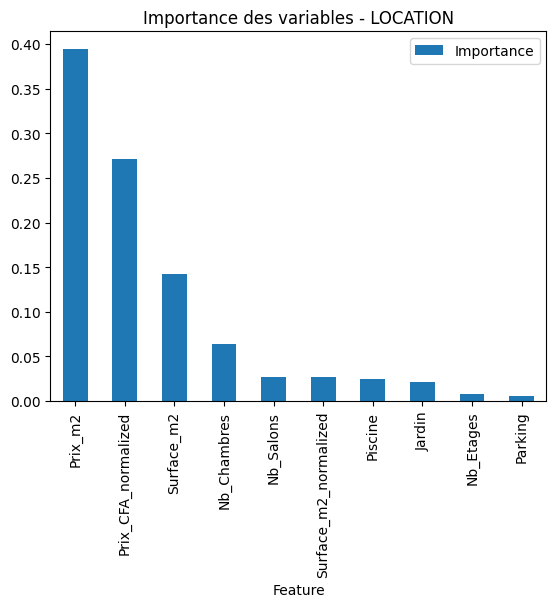

<Figure size 1000x600 with 0 Axes>

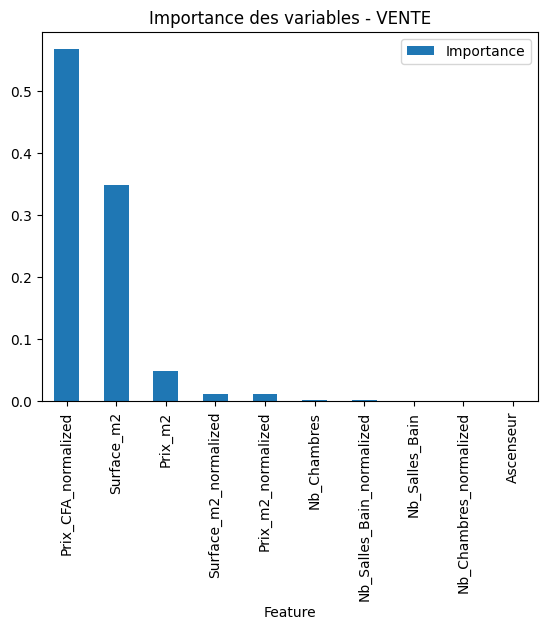

In [6]:
# ================================
# 1️⃣ IMPORTS
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ================================
# 2️⃣ PRÉPARATION DES DONNÉES
# ================================

def preparer_donnees(df):
    
    df = df.copy()
    
    # Supprimer colonnes inutiles
    df = df.drop(columns=['Titre', 'Description', 'Type_Annonce'], errors='ignore')
    
    # Encodage localisation
    if 'Localisation' in df.columns:
        df = pd.get_dummies(df, columns=['Localisation'], drop_first=True)
    
    # Garder uniquement les colonnes numériques
    df = df.select_dtypes(include=['int64', 'float64'])
    
    # Target
    y = df['Prix_CFA']
    
    # Features
    X = df.drop(columns=['Prix_CFA'])
    
    return X, y


# ================================
# 3️⃣ ENTRAÎNEMENT
# ================================

def entrainer_modele(X, y):
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # ===== Linear Regression =====
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    
    # ===== Random Forest =====
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    # ===== ÉVALUATION =====
    print("\n===== RÉSULTATS =====")
    
    print("\n--- Linear Regression ---")
    print("R2 :", r2_score(y_test, y_pred_lr))
    print("MAE :", mean_absolute_error(y_test, y_pred_lr))
    print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
    
    print("\n--- Random Forest ---")
    print("R2 :", r2_score(y_test, y_pred_rf))
    print("MAE :", mean_absolute_error(y_test, y_pred_rf))
    print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
    
    #  Retourner pour visualisation
    return lr, rf, y_test, y_pred_rf, X_test


# ================================
# 4️⃣ LOCATION
# ================================

print("\n==============================")
print(" DATASET LOCATION")
print("==============================")

X_loc, y_loc = preparer_donnees(df_location_final)

model_lr_loc, model_rf_loc, y_test_loc, y_pred_loc, X_test_loc = entrainer_modele(X_loc, y_loc)


# ================================
# 5️⃣ VENTE
# ================================

print("\n==============================")
print(" DATASET VENTE")
print("==============================")

X_vente, y_vente = preparer_donnees(df_vente_final)

model_lr_vente, model_rf_vente, y_test_vente, y_pred_vente, X_test_vente = entrainer_modele(X_vente, y_vente)


# ================================
# 6️⃣ VISUALISATION : RÉEL vs PRÉDIT
# ================================

# LOCATION
plt.figure(figsize=(8,6))
plt.scatter(y_test_loc, y_pred_loc, alpha=0.5)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("LOCATION : Réel vs Prédit")
plt.show()

# VENTE
plt.figure(figsize=(8,6))
plt.scatter(y_test_vente, y_pred_vente, alpha=0.5)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("VENTE : Réel vs Prédit")
plt.show()


# ================================
# 7️⃣ FEATURE IMPORTANCE
# ================================

# LOCATION
importances_loc = model_rf_loc.feature_importances_
features_loc = X_loc.columns

df_importance_loc = pd.DataFrame({
    'Feature': features_loc,
    'Importance': importances_loc
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
df_importance_loc.head(10).plot(kind='bar', x='Feature', y='Importance')
plt.title("Importance des variables - LOCATION")
plt.show()


# VENTE
importances_vente = model_rf_vente.feature_importances_
features_vente = X_vente.columns

df_importance_vente = pd.DataFrame({
    'Feature': features_vente,
    'Importance': importances_vente
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
df_importance_vente.head(10).plot(kind='bar', x='Feature', y='Importance')
plt.title("Importance des variables - VENTE")
plt.show()


In [7]:
import joblib

joblib.dump(model_rf_loc, "model_location.pkl")
joblib.dump(model_rf_vente, "model_vente.pkl")


['model_vente.pkl']